<a href="https://colab.research.google.com/github/briskicedteaa/CFTR-Variant-Explorer/blob/main/notebooks/CFTR_Variant_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CFTR Variant Explorer**

### UnivaBio Hackathon 2026

## Project Overview

I developed the CFTR Variant Explorer as an interactive bioinformatics project to investigate where genetic variants occur across the CFTR protein, what types of variants occur at those positions, and what characteristics of the affected protein regions might help explain differences in their potential functional effects. This notebook documents the data processing, analysis, and visualizations that I used to develop the interactive Streamlit application.

## Why I Chose CFTR

I chose CFTR because it is a well-studied protein with extensive publicly available biological and genetic data. This made it a practical protein for investigating relationships between variant location, variant consequence, sequence conservation, and protein-region characteristics. The amount of available information also allowed me to explore a meaningful biological question while connecting computational analysis to an important clinical context.

## Clinical Motivation

I chose to focus on CFTR because changes that substantially disrupt its function are associated with cystic fibrosis, a genetic disorder that can affect multiple organ systems. CFTR plays an important role in regulating chloride and bicarbonate transport across epithelial tissues, and reduced or altered CFTR function can contribute to problems involving the respiratory and digestive systems. Because different CFTR variants can affect the protein in different ways, I wanted to investigate whether patterns in variant location and protein characteristics could provide additional context for understanding their potential functional consequences.

## Research Question

Where do CFTR variants occur across the protein, what types of variants occur at those positions, and what characteristics of the affected protein regions might help explain their different effects on CFTR function?

## Purpose

The purpose of my project is to use publicly available CFTR data to investigate patterns in variant location, consequence, conservation, and protein-region characteristics. I combined these analyses into an interactive explorer so that users can examine individual CFTR positions while also seeing broader patterns across the protein. My goal is to make complex variant information easier to explore and interpret while recognizing that these analyses identify patterns and possible relationships rather than establishing the clinical effect of an individual variant or predicting outcomes for individual patients.

## What This Notebook Does

In this notebook, I document the computational work I used to develop the CFTR Variant Explorer. I begin by acquiring and organizing CFTR data, then process and characterize the recorded variants before analyzing sequence conservation and protein-region characteristics. I use these analyses to generate visualizations and identify patterns relevant to my research question. The results are then incorporated into the interactive Streamlit application, where users can explore CFTR positions and examine the variant information associated with them.

In [ ]:
#@markdown ###Inspecting Data

#@markdown I wanted to see how much rows, or variants, contain my features of interest, so for every chosen feature in features, I calculated how much variants contain them.
# Loading dataset and saving as pdf

import pandas as pd

df = pd.read_json("P13569.json")

count = df["features"].apply(lambda x: "begin" in x).sum()
count2 = df["features"].apply(lambda x: "wildType" in x).sum()
count3 = df["features"].apply(lambda x: "mutatedType" in x).sum()
count4 = df["features"].apply(lambda x: "consequenceType" in x).sum()
count5 = df["features"].apply(lambda x: "clinicalSignificances" in x).sum()
count6 = df["features"].apply(lambda x: "association" in x).sum()
print("Begin:", count,"wildType:", count2,"mutatedType:", count3,"consequenceType:", count4,"clinicalSignificances:", count5,"association:", count6)

Begin: 3664 wildType: 3664 mutatedType: 3216 consequenceType: 3664 clinicalSignificances: 2909 association: 2895


In [ ]:
#@markdown ###Creating initial df for variants and columns of interest

#@markdown After inspecting the dataset, I decided I did not need all the features I initally chose, so I just kept begin, wildType, mutatedType, and consequenceType

variants = []

for feature in df["features"]:
  variants.append({
      "Position": int(feature["begin"]),
      "WildType": feature["wildType"],
      "MutatedType": feature.get("mutatedType"),
      "Consequence": feature["consequenceType"]
  })

variants_df = pd.DataFrame(variants)
variants_df.head()

,Position,WildType,MutatedType,Consequence
0,1,M,None,initiator codon variant
1,1,M,I,missense
2,1,M,K,missense
3,1,M,R,missense
4,1,M,T,missense


In [ ]:
#@markdown Downloading variants_df as csv to store in CFTR-Variant-Explorer/data (and eventually use later while building the app)

from google.colab import files

variants_df.to_csv('CFTR_variants.csv', index = False)
files.download('CFTR_variants.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@markdown Counting mutations for every amino acid position in the dataset

variants_df["Position"].value_counts().head(20)

,count
Position,
1098,8
508,8
137,8
311,7
14,7
17,7
1295,7
1023,7
1130,6


In [ ]:
#@markdown Counting how many variants are associated with the corresponding consequences

variants_df["Consequence"].value_counts()

,count
Consequence,
missense,2809
frameshift,459
stop gained,316
inframe deletion,52
-,13
insertion,11
stop lost,3
initiator codon variant,1


In [ ]:
missense_df = variants_df[
    variants_df["Consequence"] == "missense"
].copy()

missense_df.shape

(2809, 4)

In [ ]:
#@markdown Identifying Mutation Hotspots

# Calculating the number of unique mutations at each amino acid position
position_variants = (
    variants_df.dropna(subset=["MutatedType"])
    .groupby("Position")["MutatedType"]
    .nunique()
    .sort_values(ascending=False)
)

position_variants.head(20)

,MutatedType
Position,
117,6
1098,6
192,6
317,6
579,6
530,6
506,6
508,6
1154,5


In [ ]:
#@markdown ### Defining Protein Regions

#@markdown To investigate whether variants are distributed differently across broad sections of the CFTR protein, I divided the protein sequence into N-terminal, Middle, and C-terminal regions based on amino acid position

variants_df["Region"] = pd.cut(
    variants_df["Position"],
    bins=[0, 493, 986, 1480],
    labels=["N-terminal", "Middle", "C-terminal"]
)

variants_df

,Position,WildType,MutatedType,Consequence,Region
0,1,M,None,initiator codon variant,N-terminal
1,1,M,I,missense,N-terminal
2,1,M,K,missense,N-terminal
3,1,M,R,missense,N-terminal
4,1,M,T,missense,N-terminal
...,...,...,...,...,...
3659,1478,T,R,missense,C-terminal
3660,1479,R,K,missense,C-terminal
3661,1480,L,P,missense,C-terminal
3662,1481,*,Q,stop lost,NaN


In [ ]:
#@markdown ###Variant Consequences Across Protein Region

#@markdown To investigate whether different types of CFTR variants are distributed differently across the protein, I compared variant consequences across the N-terminal, Middle, and C-terminal regions. I calculated both the number of recorded variants in each region and the percentage of each region represented by each consequence type. This allows me to compare both the overall number of variants and the relative distribution of variant consequences across regions.

variant_region_counts = pd.crosstab(
    variants_df["Region"],
    variants_df["Consequence"]
)

variant_region_percent = pd.crosstab(
    variants_df["Region"],
    variants_df["Consequence"],
    normalize="index"
) * 100

print("Region Counts:", variant_region_counts)
print("Region Percent:", variant_region_percent.round(2))

Region Counts: Consequence  -  frameshift  inframe deletion  initiator codon variant  \
Region                                                                  
N-terminal   6         170                17                        1   
Middle       6         143                15                        0   
C-terminal   1         146                20                        0   

Consequence  insertion  missense  stop gained  stop lost  
Region                                                    
N-terminal           6       990          110          0  
Middle               1       921          107          0  
C-terminal           4       898           99          1  
Region Percent: Consequence     -  frameshift  inframe deletion  initiator codon variant  \
Region                                                                     
N-terminal   0.46       13.08              1.31                     0.08   
Middle       0.50       11.99              1.26                     0.00   
C-te

In [ ]:
#@markdown ### Missense Amino Acid Substitutions

#@markdown To further characterize missense variants, I examined which amino acid substitutions occur most frequently in the dataset. I grouped variants by their original amino acid and the amino acid replacing it, then counted the number of recorded variants for each substitution. This provides a more detailed view of the types of amino acid changes represented among the missense variants.


substitution_counts = (
    variants_df[
        variants_df["Consequence"] == "missense"
    ]
    .groupby(["WildType", "MutatedType"])
    .size()
    .sort_values(ascending=False)
)

print(substitution_counts.head(20))

WildType  MutatedType
I         V              77
L         F              67
F         L              65
L         P              57
I         T              55
A         V              53
L         V              46
A         T              45
G         R              44
E         K              42
T         I              39
V         L              38
K         E              38
G         V              35
R         G              35
V         I              35
T         A              35
S         R              33
G         E              33
V         A              33
dtype: int64


###Evolutionary Conservation Analysis

To investigate whether the regions affected by CFTR variants show differences in evolutionary conservation, I compared CFTR sequences from different organisms. I used publicly available UniProt CFTR entries from **ID: P13569 CFTR_HUMAN** to examine how conserved the protein sequence is across species.

I used Biopython to retrieve and process the protein sequences and to prepare them for sequence alignment. Comparing CFTR across organisms provides an evolutionary perspective that complements the variant-level analysis. Positions or regions that remain similar across species may indicate evolutionary constraint and can provide additional context when investigating their potential functional importance.

This analysis is used as supporting evidence for patterns in the dataset rather than as proof that conservation alone determines the clinical or functional effect of a variant.

In [ ]:
#@markdown Installs/Imports

!pip install BioPython
from Bio import SeqIO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.9 MB/s eta 0:00:00


In [ ]:
#@markdown Parsing file, coverting to FASTA and viewing records

import gzip

with gzip.open("uniprotkb_CFTR_2026_08_24.fasta.gz", "rt") as handle:
  records = list(SeqIO.parse(handle, "fasta"))

SeqIO.write(records, "CFTR_Homologs.fasta", "fasta")

15201

In [ ]:
#@markdown Viewing description to see what the file contains

for record in SeqIO.parse("CFTR_Homologs.fasta", "fasta"):
    print(f"Description: {record.description}")

Streaming output truncated to the last 5000 lines.
Description: tr|A0A8C5KSY1|A0A8C5KSY1_JACJA Adhesion G-protein coupled receptor G2 OS=Jaculus jaculus OX=51337 GN=Adgrg2 PE=3 SV=1
Description: tr|A0A8C5KTN6|A0A8C5KTN6_JACJA Adhesion G-protein coupled receptor G2 OS=Jaculus jaculus OX=51337 GN=Adgrg2 PE=3 SV=1
Description: tr|A0A8C5KU86|A0A8C5KU86_JACJA Exportin-2 OS=Jaculus jaculus OX=51337 GN=Cse1l PE=3 SV=1
Description: tr|A0A8C5KY65|A0A8C5KY65_JACJA ATP-binding cassette, sub-family C member 8 OS=Jaculus jaculus OX=51337 GN=Abcc8 PE=3 SV=1
Description: tr|A0A8C5L5N7|A0A8C5L5N7_JACJA ABC transporter domain-containing protein OS=Jaculus jaculus OX=51337 PE=3 SV=1
Description: tr|A0A8C5L7Z9|A0A8C5L7Z9_JACJA ABC transporter domain-containing protein OS=Jaculus jaculus OX=51337 PE=3 SV=1
Description: tr|A0A8C5LDP6|A0A8C5LDP6_JACJA ABC transmembrane type-1 domain-containing protein OS=Jaculus jaculus OX=51337 PE=4 SV=1
Description: tr|A0A8C5LU58|A0A8C5LU58_9ANUR Adhesion G-protein couple

In [ ]:
#@markdown Uniprot datasets do not always contain the same protein. In this cell, I filter the dataset for only CFTR proteins based on its description name, I remove fragments (uncomplete proteins), and I drop duplicates.

#@markdown This cell is heavily borrowed from my repository, FOXP2-Project/notebooks/01_FOXP2_dataset_preparation.ipynb

import pandas as pd

# Created df and added columns

df = pd.DataFrame({
    "ID": [record.id for record in records],
    "Description": [record.description for record in records],
    "Sequence": [str(record.seq) for record in records],
    "Length": [len(record.seq) for record in records],
})

# Filtering for only CFTR in description column

CFTR_df = df[
    df["Description"].str.contains(
        "Cystic fibrosis transmembrane conductance regulator",
        case=False,
        na=False
    )
].copy()

# Removed proteins containing "Fragment" in description

CFTR_df = CFTR_df[
    ~CFTR_df["Description"].str.contains(
        "Fragment",
        case=False,
        na=False
    )
].copy()

# Dropped duplicates

CFTR_df = CFTR_df.drop_duplicates(
    subset="Sequence",
    keep="first"

).copy()

print("Remaining Proteins:", len(CFTR_df))
print("Total Proteins:", len(df))
print("Remaining duplicate sequences:", CFTR_df["Sequence"].duplicated().sum())
df.head()

Remaining Proteins: 1649
Total Proteins: 15201
Remaining duplicate sequences: 0


,ID,Description,Sequence,Length
0,tr|A0A087Y0E6|A0A087Y0E6_POEFO,tr|A0A087Y0E6|A0A087Y0E6_POEFO Cystic fibrosis...,MEKVRKDGKKNPAATANILSKIFFWWLNPLFRIGYKRRLEEEDMYE...,1322
1,tr|A0A091E3B6|A0A091E3B6_FUKDA,tr|A0A091E3B6|A0A091E3B6_FUKDA Cystic fibrosis...,MYSVLPQDRSKYLGEELQGYWDREVLRAEKDTRKPSLTKAIIKCYW...,1311
2,tr|A0A0G2K3B1|A0A0G2K3B1_RAT,tr|A0A0G2K3B1|A0A0G2K3B1_RAT Cystic fibrosis t...,MDLEKLTGGGGGRKEEEREEKGEQSEGKDSVGEGREREEGGEREEG...,1665
3,sp|A0A0H2ZD27|CIF_PSEAB,sp|A0A0H2ZD27|CIF_PSEAB CFTR inhibitory factor...,MILDRLCRGLLAGIALTFSLGGFAAEEFPVPNGFESAYREVDGVKL...,319
4,tr|A0A0U3J5G9|A0A0U3J5G9_ORYME,tr|A0A0U3J5G9|A0A0U3J5G9_ORYME Cystic fibrosis...,MEKVGKNNPAATANIFSKIFFWWLNPLFRIGSKRRLDEDDMFEVLP...,1324


In [ ]:
#@markdown Despite the prior filtering, proteins with substanially short protein sequences remain in the dataset. This could interfere with the sequence alignment process, so I only kept proteins equal to or above 1400 AA, and dropped proteins below that amount. Human CFTR is 1480 AA long.

CFTR_df[
    ["ID", "Description", "Length"]
].sort_values("Length").head(30)

# Dropped proteins below 1400 AA

CFTR_df = CFTR_df[
    CFTR_df["Length"] >= 1400
].copy()

below_1400 = (CFTR_df["Length"] < 1400).sum()

print("Proteins remaining:", len(CFTR_df))
print("Proteins removed below 1400 aa:", below_1400)
print("1400 aa or longer:", (CFTR_df["Length"] >= 1400).sum())
CFTR_df["Length"].describe()

Proteins remaining: 1008
Proteins removed below 1400 aa: 0
1400 aa or longer: 1008


,Length
count,1008.000000
mean,1474.126984
std,38.861168
min,1400.000000
25%,1454.000000
50%,1480.000000
75%,1488.000000
max,1750.000000


In [ ]:
#@markdown Saving CFTR_df as csv to store in CFTR-Variation-Explorer/data

from google.colab import files

CFTR_df.to_csv('CFTR_df.csv', index = False)
files.download('CFTR_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@markdown ### Preparing Sequences for Multiple Sequence Alignment

#@markdown I converted the filtered CFTR sequences into FASTA format so they could be used as input for Clustal Omega. Each sequence is labeled with its UniProt record ID, allowing the resulting alignment to be traced back to the corresponding protein sequence.

from google.colab import files

with open("CFTR_Homologs.fasta", "w") as f:
    for _, row in CFTR_df.iterrows():
        f.write(f">{row['ID']}\n")
        f.write(f"{row['Sequence']}\n")

files.download("CFTR_Homologs.fasta")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@markdown ## Checking the Multiple Sequence Alignment

#@markdown After generating the multiple sequence alignment with Clustal Omega, I loaded the alignment using Biopython's `AlignIO` module. I inspected the aligned sequence length and the number of gap positions to verify that the alignment was successfully read and contained the expected alignment structure. I also inspected the first 200 aligned positions as a basic visual quality check before using the alignment for conservation analysis.

from Bio import AlignIO

alignment = AlignIO.read(
    "clustalo-I20260824-221828-0411-59024886-p1m.aln-clustal_num",
    "clustal"
)

seq = str(alignment[0].seq)
print("Aligned sequence length:", len(seq))
print("Number of gaps:", seq.count("-"))
print("First 200 aligned positions:", seq[:200])

Aligned sequence length: 4193
Number of gaps: 2477
First 200 aligned positions: ------------------------------------------------------------------------------------------MDFCRRYKFLHI--------------------------------------------------------------------------LPR-------PAKRIVWSWRA---


In [ ]:
#@markdown ### Calculating Per-Position Conservation

#@markdown I calculated a conservation score for every position in the multiple sequence alignment. For each alignment position, I excluded gap characters and counted how frequently each amino acid occurred among the remaining sequences. I then calculated the proportion represented by the most common amino acid.

#@markdown A score of 1 indicates that all non-gap sequences contain the same amino acid at that alignment position, while lower scores indicate greater variation across the aligned sequences. I used these per-position conservation scores as the basis for examining how conserved different regions of CFTR are.

from collections import Counter

conservation = []

for i in range(alignment.get_alignment_length()):
  column = []

  for record in alignment:
    amino_acid = record.seq[i]
    if amino_acid != "-":
        column.append(amino_acid)


  if column:
    counts = Counter(column)
    most_common_count = counts.most_common(1)[0][1]
    score = most_common_count / len(column)

  else:
    score = None

  conservation.append(score)

conservation_df = pd.DataFrame({
    "Alignment_Position": range(1, len(conservation) + 1),
    "Conservation": conservation
})

print(conservation_df.head())
print(conservation_df["Conservation"].describe())

   Alignment_Position  Conservation
0                   1          1.00
1                   2          1.00
2                   3          1.00
3                   4          1.00
4                   5          0.75
count    4193.000000
mean        0.716346
std         0.277990
min         0.125000
25%         0.489989
50%         0.793177
75%         1.000000
max         1.000000
Name: Conservation, dtype: float64


In [ ]:
#@markdown ### Identifying the Human CFTR Sequence

#@markdown I first identified the human CFTR sequence within the multiple sequence alignment so that I could use it as the reference for connecting the evolutionary analysis to human CFTR amino-acid positions.

for record in alignment:
    if "HUMAN" in record.id.upper() or "HUMAN" in record.description.upper():
        print(record.id, record.description)

tr|A0A8V8TNN0|A0A8V8TNN0_HUMAN tr|A0A8V8TNN0|A0A8V8TNN0_HUMAN
tr|A0A8V8TNH2|A0A8V8TNH2_HUMAN tr|A0A8V8TNH2|A0A8V8TNH2_HUMAN
sp|P13569|CFTR_HUMAN sp|P13569|CFTR_HUMAN


In [ ]:
#@markdown ## Checking the Human CFTR Sequence

#@markdown I checked the length of the human CFTR sequence in the alignment and counted its non-gap residues. This provides a basic quality check that the human reference sequence was identified correctly and is represented as expected within the alignment.


human_record = next(
    record for record in alignment
    if record.id == "sp|P13569|CFTR_HUMAN"
)

print("Human sequence length:", len(human_record.seq))
print("Human non-gap residues:", sum(aa != "-" for aa in human_record.seq))

Human sequence length: 4193
Human non-gap residues: 1480


In [ ]:
#@markdown ### Mapping Human CFTR Positions to Alignment Positions

#@markdown Because gaps introduced during sequence alignment can shift alignment positions relative to the original protein sequence, I created a mapping between human CFTR amino-acid positions and their corresponding positions in the multiple sequence alignment. This allows the conservation scores calculated from the alignment to be connected back to the actual positions used in my CFTR variant dataset.


human_position = 0
mapping = []

for Alignment_Position, amino_acid in enumerate(human_record.seq, start=1):

  if amino_acid != "-":
    human_position += 1
    mapping.append({
        "Human_Position": human_position,
        "Alignment_Position": Alignment_Position
    })

position_map = pd.DataFrame(mapping)
print(position_map.head())
print(position_map.tail())
print("Mapped human positions:", len(position_map))

   Human_Position  Alignment_Position
0               1                 444
1               2                 445
2               3                 446
3               4                 447
4               5                 448
      Human_Position  Alignment_Position
1475            1476                3903
1476            1477                3904
1477            1478                3905
1478            1479                3906
1479            1480                3907
Mapped human positions: 1480


In [ ]:
#@markdown ### Linking Human Positions to Conservation

#@markdown I merged the human CFTR position mapping with the conservation scores from the multiple sequence alignment. This connects each human amino-acid position to the conservation score calculated for its corresponding alignment position. I also inspected the resulting data as a quality check before combining it with the variant data.

position_conservation = position_map.merge(
    conservation_df,
    on="Alignment_Position",
    how="left"
)

print(position_conservation.head())
print(position_conservation[position_conservation["Human_Position"] == 508])

   Human_Position  Alignment_Position  Conservation
0               1                 444      0.809598
1               2                 445      0.763804
2               3                 446      0.417598
3               4                 447      0.740371
4               5                 448      0.773533
     Human_Position  Alignment_Position  Conservation
507             508                1645      0.996028


In [ ]:
#@markdown ### Linking Conservation to Variant Distribution

#@markdown I combined the conservation data with the number of recorded CFTR variants at each human amino-acid position. This creates a final position-level dataset that allows me to examine the relationship between evolutionary conservation and variant distribution across human CFTR.


variant_counts = (
    variants_df
    .groupby("Position")
    .size()
    .reset_index(name="Variant_Count")
)

variant_counts = variant_counts.rename(
    columns={"Position": "Human_Position"}
)

final_position_df = position_conservation.merge(
    variant_counts,
    on="Human_Position",
    how="left"
)

final_position_df["Variant_Count"] = (
    final_position_df["Variant_Count"]
    .fillna(0)
    .astype(int)
)

print(final_position_df.head())
print(final_position_df.shape)

   Human_Position  Alignment_Position  Conservation  Variant_Count
0               1                 444      0.809598              6
1               2                 445      0.763804              3
2               3                 446      0.417598              3
3               4                 447      0.740371              4
4               5                 448      0.773533              3
(1480, 4)


In [ ]:
#@markdown Downloading final_position_df to store in CFTR-Variant-Explorer/data

from google.colab import files

final_position_df.to_csv('FinalPosition.csv', index = False)
files.download('FinalPosition.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

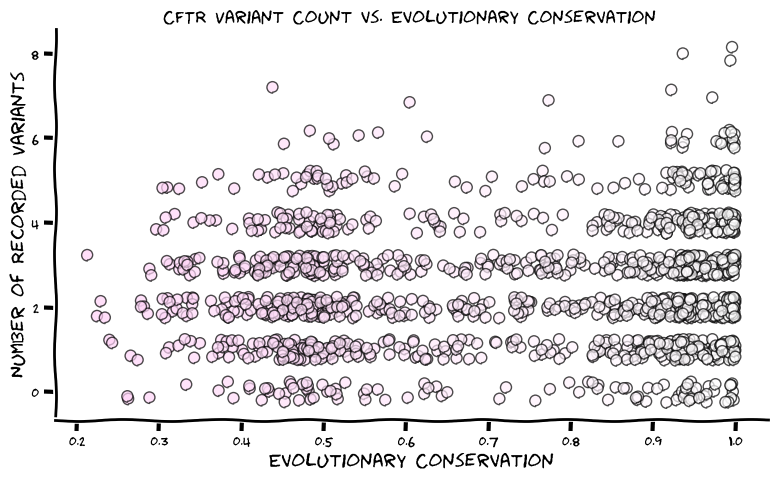

In [ ]:
#@markdown ### Exploring Variant Distribution and Evolutionary Conservation

#@markdown I explored whether the number of recorded CFTR variants at a given human amino-acid position varies with the evolutionary conservation of that position. I plotted conservation scores against the number of recorded variants to look for patterns in how variant distribution relates to sequence conservation across CFTR.

#@markdown Because multiple positions can have the same variant count, I added a small amount of random vertical jitter to separate overlapping points visually. This does not change the underlying variant counts or conservation values.

#@markdown This analysis is exploratory and does not establish that evolutionary conservation causes a position to have more or fewer recorded variants.


from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

custom_pink_gradient = LinearSegmentedColormap.from_list(
    "pink_to_white",
    ["#ffd1f7", "#ffffff"]
)

np.random.seed(42)

final_position_df["Variant_Count_Jittered"] = (
    final_position_df["Variant_Count"]
    + np.random.uniform(-0.25, 0.25, len(final_position_df))
)

with plt.xkcd():
    mpl.rcParams["font.family"] = "Humor Sans"

    fig, ax = plt.subplots(figsize=(8, 5))

    scatter = ax.scatter(
        final_position_df["Conservation"],
        final_position_df["Variant_Count_Jittered"],
        c=final_position_df["Conservation"],
        cmap=custom_pink_gradient,
        edgecolor="#000000",
        linewidth=1,
        s=50,
        alpha=0.7,
        zorder=3
    )

    ax.set_xlabel(
        "Evolutionary Conservation",
        weight="bold",
        fontname="Humor Sans"
    )

    ax.set_ylabel(
        "Number of Recorded Variants",
        weight="bold",
        fontname="Humor Sans"
    )

    ax.set_title(
        "CFTR Variant Count vs. Evolutionary Conservation",
        weight="bold",
        fontsize=13,
        fontname="Humor Sans"
    )

    ax.tick_params(colors="#000000", labelsize=10)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname("Humor Sans")

    ax.grid(
        axis="y",
        linestyle="-",
        alpha=0.3,
        color="#000000"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.spines["left"].set_color("#000000")
    ax.spines["bottom"].set_color("#000000")
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    plt.savefig("Figure2.png")
    plt.tight_layout()
    plt.show()

In [ ]:
#@markdown ### Quantifying the Relationship

#@markdown To complement the scatter plot, I calculated the Pearson correlation coefficient between evolutionary conservation and the number of recorded variants at each human CFTR position. This provides a numerical measure of the strength and direction of their linear association.

#@markdown The correlation coefficient helps quantify the pattern observed in the visualization, but it does not establish that conservation causes differences in variant distribution or that one variable directly determines the other.

corr = final_position_df["Conservation"].corr(
    final_position_df["Variant_Count"]
)

print("Pearson correlation:", corr)

Pearson correlation: 0.10134511817654995


In [ ]:
#@markdown ### Comparing Variant Counts Across Conservation Groups

#@markdown To further explore the relationship between evolutionary conservation and variant distribution, I divided human CFTR positions into three groups based on their conservation scores: Low, Medium, and High. These groups represent relative conservation within this dataset rather than fixed biological conservation thresholds.

#@markdown I then compared the mean, median, minimum, and maximum number of recorded variants across the three groups. This provides another way to examine whether variant counts differ between positions with relatively lower and higher evolutionary conservation.

final_position_df["Conservation_Group"] = pd.qcut(
    final_position_df["Conservation"],
    q=3,
    labels=["Low", "Medium", "High"]
)

summary = final_position_df.groupby(
    "Conservation_Group"
)["Variant_Count"].agg(
    ["mean", "median", "min", "max"]
)

print(summary)

                        mean  median  min  max
Conservation_Group                            
Low                 2.330629     2.0    0    7
Medium              2.397566     2.0    0    7
High                2.694332     3.0    0    8


/tmp/ipykernel_1475/2858707241.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = final_position_df.groupby(


In [ ]:
#@markdown ### Comparing Conservation Across CFTR Regions

#@markdown I compared evolutionary conservation across the N-terminal, Middle, and C-terminal regions of human CFTR. For each region, I calculated the mean, median, minimum, and maximum conservation scores.

#@markdown This allows me to examine whether some regions of CFTR are more evolutionarily conserved than others and provides additional context for understanding where variants are distributed across the protein.


region_conservation = (
    final_position_df
    .merge(
        variants_df[["Position", "Region"]].drop_duplicates(),
        left_on="Human_Position",
        right_on="Position",
        how="inner"
    )
     .groupby("Region")["Conservation"]
    .agg(["mean", "median", "min", "max"])
)

print(region_conservation)

                mean    median       min  max
Region                                       
N-terminal  0.757008  0.847619  0.239535  1.0
Middle      0.711997  0.775428  0.212581  1.0
C-terminal  0.768154  0.875752  0.234064  1.0


/tmp/ipykernel_1475/1834700872.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Region")["Conservation"]


In [ ]:
#@markdown ### Assigning CFTR Protein Domains

#@markdown I assigned human CFTR amino-acid positions to five major functional regions: TMD1, NBD1, the R domain, TMD2, and NBD2. I used the curated domain and region annotations for human CFTR (UniProt accession P13569) to define the residue ranges used in this analysis.

#@markdown The ranges used were TMD1 (81–365), NBD1 (423–646), R domain (654–831), TMD2 (859–1155), and NBD2 (1210–1443). Positions outside these annotated regions were classified as "Other." These assignments allow me to compare evolutionary conservation and variant distribution across the major functional regions of CFTR.

#@markdown **Source:** UniProtKB. *CFTR_HUMAN (P13569), Family & Domains annotations.* https://www.uniprot.org/uniprotkb/P13569


def cftr_domain(position):
    if 81 <= position <= 365:
        return "TMD1"
    elif 423 <= position <= 646:
        return "NBD1"
    elif 654 <= position <= 831:
        return "R domain"
    elif 859 <= position <= 1155:
        return "TMD2"
    elif 1210 <= position <= 1443:
        return "NBD2"
    else:
        return "Other"

final_position_df["CFTR_Domain"] = (
    final_position_df["Human_Position"].apply(cftr_domain)
)

print(
    final_position_df["CFTR_Domain"].value_counts()
    .sort_index()
)

CFTR_Domain
NBD1        224
NBD2        234
Other       262
R domain    178
TMD1        285
TMD2        297
Name: count, dtype: int64


In [ ]:
#@markdown ### Comparing Variant-Containing Positions Across CFTR Domains

#@markdown I compared the major CFTR domains based on their length and the number of amino-acid positions within each domain that contain at least one recorded variant. I then calculated the percentage of positions within each domain that have recorded variants.

#@markdown Because CFTR domains differ in length, comparing the raw number of variant-containing positions alone could be misleading. Calculating the percentage allows me to compare variant distribution across domains while accounting for their different sizes.

domain_summary = (
    final_position_df
    .groupby("CFTR_Domain")
    .agg(
        Domain_Length=("Human_Position", "count"),
        Positions_With_Variants=(
            "Variant_Count",
            lambda x: (x > 0).sum()
        )
    )
)

domain_summary["Variant_Position_Percent"] = (
    domain_summary["Positions_With_Variants"]
    / domain_summary["Domain_Length"]
    * 100
)

print(domain_summary)

             Domain_Length  Positions_With_Variants  Variant_Position_Percent
CFTR_Domain                                                                  
NBD1                   224                      217                 96.875000
NBD2                   234                      220                 94.017094
Other                  262                      243                 92.748092
R domain               178                      163                 91.573034
TMD1                   285                      262                 91.929825
TMD2                   297                      278                 93.602694


In [ ]:
#@markdown ### Comparing Variant Consequences Across CFTR Domains

#@markdown I mapped each recorded CFTR variant to the protein domain containing its amino-acid position and then compared the distribution of variant consequence types across domains.

#@markdown This allows me to examine whether certain types of variants are more frequently represented in particular regions of CFTR. Comparing consequence types across domains provides additional context for understanding how variant distribution relates to the functional organization of the protein.


variants_with_domains = variants_df.merge(
    final_position_df[
        ["Human_Position", "CFTR_Domain"]
    ],
    left_on="Position",
    right_on="Human_Position",
    how="left"
)

domain_consequence_counts = pd.crosstab(
    variants_with_domains["CFTR_Domain"],
    variants_with_domains["Consequence"]
)

print(domain_consequence_counts)

Consequence  -  frameshift  inframe deletion  initiator codon variant  \
CFTR_Domain                                                             
NBD1         1          68                11                        0   
NBD2         1          70                 3                        0   
Other        1          90                 7                        1   
R domain     4          51                 5                        0   
TMD1         4          96                12                        0   
TMD2         2          84                14                        0   

Consequence  insertion  missense  stop gained  stop lost  
CFTR_Domain                                               
NBD1                 0       479           47          0  
NBD2                 2       431           49          0  
Other                4       459           67          1  
R domain             0       286           47          0  
TMD1                 4       596           63          0  
TM

In [ ]:
#@markdown ### Comparing Variant Consequence Proportions Across CFTR Domains

#@markdown I converted the variant consequence counts within each CFTR domain into percentages. This allows me to compare the composition of variant consequences across domains without relying only on raw variant counts.

#@markdown By examining the proportion of each consequence type within each domain, I can identify differences in the types of variants represented across the functional regions of CFTR.

domain_consequence_percent = (
    pd.crosstab(
        variants_with_domains["CFTR_Domain"],
        variants_with_domains["Consequence"],
        normalize="index"
    ) * 100
)

print(domain_consequence_percent.round(2))

Consequence     -  frameshift  inframe deletion  initiator codon variant  \
CFTR_Domain                                                                
NBD1         0.17       11.22              1.82                     0.00   
NBD2         0.18       12.59              0.54                     0.00   
Other        0.16       14.29              1.11                     0.16   
R domain     1.02       12.98              1.27                     0.00   
TMD1         0.52       12.39              1.55                     0.00   
TMD2         0.28       11.97              1.99                     0.00   

Consequence  insertion  missense  stop gained  stop lost  
CFTR_Domain                                               
NBD1              0.00     79.04         7.76       0.00  
NBD2              0.36     77.52         8.81       0.00  
Other             0.63     72.86        10.63       0.16  
R domain          0.00     72.77        11.96       0.00  
TMD1              0.52     76.90     

In [ ]:
#@markdown ### Comparing Conservation Across CFTR Domains

#@markdown I summarized the evolutionary conservation scores within each CFTR domain by calculating the mean, median, minimum, and maximum conservation. This allows me to compare the overall conservation of the major functional regions of CFTR and identify domains that show relatively higher or lower conservation across the aligned sequences.

#@markdown These results provide additional evolutionary context for the variant distribution analyses by showing how the regions containing recorded variants differ in their degree of conservation.

domain_conservation = (
    final_position_df
    .groupby("CFTR_Domain")["Conservation"]
    .agg(["mean", "median", "min", "max"])
)

print(domain_conservation.round(3))

              mean  median    min    max
CFTR_Domain                             
NBD1         0.820   0.922  0.313  1.000
NBD2         0.791   0.893  0.304  1.000
Other        0.693   0.705  0.234  0.999
R domain     0.640   0.560  0.213  0.999
TMD1         0.768   0.894  0.369  1.000
TMD2         0.729   0.846  0.224  1.000


In [ ]:
#@markdown ### Consolidating Domain-Level Results

#@markdown I combined the results from my domain-level analyses into a single summary table. This table brings together the proportions of variant consequences, evolutionary conservation, and the percentage of positions containing recorded variants for each CFTR domain.

#@markdown Creating this consolidated dataset allowed me to keep the main findings from the evolutionary and variant analyses together and use them as a reference when developing the interactive CFTR Variant Explorer.


domain_results = domain_consequence_percent.copy()

domain_results["Mean_Conservation"] = (
    domain_conservation["mean"]
)

domain_results["Median_Conservation"] = (
    domain_conservation["median"]
)

domain_results["Variant_Position_Percent"] = (
    domain_summary["Variant_Position_Percent"]
)

print(domain_results.round(2))

Consequence     -  frameshift  inframe deletion  initiator codon variant  \
CFTR_Domain                                                                
NBD1         0.17       11.22              1.82                     0.00   
NBD2         0.18       12.59              0.54                     0.00   
Other        0.16       14.29              1.11                     0.16   
R domain     1.02       12.98              1.27                     0.00   
TMD1         0.52       12.39              1.55                     0.00   
TMD2         0.28       11.97              1.99                     0.00   

Consequence  insertion  missense  stop gained  stop lost  Mean_Conservation  \
CFTR_Domain                                                                   
NBD1              0.00     79.04         7.76       0.00               0.82   
NBD2              0.36     77.52         8.81       0.00               0.79   
Other             0.63     72.86        10.63       0.16               0.69

### Training The ML Model

In [36]:
import numpy as np

variants_df = pd.read_csv("CFTR_variants.csv")
position_df = pd.read_csv("FinalPosition.csv")

position_lookup = dict(
    zip(
        position_df["Human_Position"],
        position_df["Alignment_Position"]
    )
)

def get_features(row):
    alignment_position = position_lookup.get(row["Position"])

    if pd.isna(alignment_position):
        return pd.Series({
            "Alignment_Position": np.nan,
            "Human_Residue_Frequency": np.nan,
            "Mutant_Residue_Frequency": np.nan,
            "Gap_Frequency": np.nan,
            "Distinct_Residues": np.nan,
            "Mutant_Observed": np.nan
        })

    column = alignment[:, int(alignment_position) - 1]
    counts = Counter(column)
    total = len(column)
    non_gap = total - counts.get("-", 0)

    return pd.Series({
        "Alignment_Position": alignment_position,
        "Human_Residue_Frequency": counts.get(row["WildType"], 0) / non_gap,
        "Mutant_Residue_Frequency": (
            counts.get(row["MutatedType"], 0) / non_gap
            if row["MutatedType"] not in ["", "*"]
            else np.nan
        ),
        "Gap_Frequency": counts.get("-", 0) / total,
        "Distinct_Residues": len([x for x in counts if x != "-"]),
        "Mutant_Observed": (
            counts.get(row["MutatedType"], 0) > 0
            if row["MutatedType"] not in ["", "*"]
            else False
        )
    })

ml_features = variants_df.apply(get_features, axis=1)

ml_df = pd.concat(
    [variants_df, ml_features],
    axis=1
)

print(ml_df.head(10))

   Position WildType MutatedType              Consequence  Alignment_Position  \
0         1        M         NaN  initiator codon variant               444.0   
1         1        M           I                 missense               444.0   
2         1        M           K                 missense               444.0   
3         1        M           R                 missense               444.0   
4         1        M           T                 missense               444.0   
5         1        M           V                 missense               444.0   
6         2        Q         NaN               frameshift               445.0   
7         2        Q           *              stop gained               445.0   
8         2        Q           P                 missense               445.0   
9         3        R         NaN               frameshift               446.0   

   Human_Residue_Frequency  Mutant_Residue_Frequency  Gap_Frequency  \
0                 0.809598           

In [37]:
aa_properties = {
    "A": {"hydrophobicity": 1.8, "polarity": 8.1, "charge": 0, "size": 89.1},
    "R": {"hydrophobicity": -4.5, "polarity": 10.5, "charge": 1, "size": 174.2},
    "N": {"hydrophobicity": -3.5, "polarity": 11.6, "charge": 0, "size": 132.1},
    "D": {"hydrophobicity": -3.5, "polarity": 13.0, "charge": -1, "size": 133.1},
    "C": {"hydrophobicity": 2.5, "polarity": 5.5, "charge": 0, "size": 121.2},
    "Q": {"hydrophobicity": -3.5, "polarity": 10.5, "charge": 0, "size": 146.2},
    "E": {"hydrophobicity": -3.5, "polarity": 12.3, "charge": -1, "size": 147.1},
    "G": {"hydrophobicity": -0.4, "polarity": 9.0, "charge": 0, "size": 75.1},
    "H": {"hydrophobicity": -3.2, "polarity": 10.4, "charge": 0, "size": 155.2},
    "I": {"hydrophobicity": 4.5, "polarity": 5.2, "charge": 0, "size": 131.2},
    "L": {"hydrophobicity": 3.8, "polarity": 4.9, "charge": 0, "size": 131.2},
    "K": {"hydrophobicity": -3.9, "polarity": 11.3, "charge": 1, "size": 146.2},
    "M": {"hydrophobicity": 1.9, "polarity": 5.7, "charge": 0, "size": 149.2},
    "F": {"hydrophobicity": 2.8, "polarity": 5.2, "charge": 0, "size": 165.2},
    "P": {"hydrophobicity": -1.6, "polarity": 8.0, "charge": 0, "size": 115.1},
    "S": {"hydrophobicity": -0.8, "polarity": 9.2, "charge": 0, "size": 105.1},
    "T": {"hydrophobicity": -0.7, "polarity": 8.6, "charge": 0, "size": 119.1},
    "W": {"hydrophobicity": -0.9, "polarity": 5.4, "charge": 0, "size": 204.2},
    "Y": {"hydrophobicity": -1.3, "polarity": 6.2, "charge": 0, "size": 181.2},
    "V": {"hydrophobicity": 4.2, "polarity": 5.9, "charge": 0, "size": 117.1}
}

def mutation_features(row):
    wt = row["WildType"]
    mut = row["MutatedType"]

    if wt not in aa_properties or pd.isna(mut) or mut not in aa_properties:
        return pd.Series({
            "Hydrophobicity_Change": np.nan,
            "Polarity_Change": np.nan,
            "Charge_Change": np.nan,
            "Size_Change": np.nan
        })

    return pd.Series({
        "Hydrophobicity_Change": aa_properties[mut]["hydrophobicity"] - aa_properties[wt]["hydrophobicity"],
        "Polarity_Change": aa_properties[mut]["polarity"] - aa_properties[wt]["polarity"],
        "Charge_Change": aa_properties[mut]["charge"] - aa_properties[wt]["charge"],
        "Size_Change": aa_properties[mut]["size"] - aa_properties[wt]["size"]
    })

mutation_features_df = ml_df.apply(mutation_features, axis=1)

ml_df = pd.concat(
    [ml_df, mutation_features_df],
    axis=1
)

print(ml_df.head(10))

   Position WildType MutatedType              Consequence  Alignment_Position  \
0         1        M         NaN  initiator codon variant               444.0   
1         1        M           I                 missense               444.0   
2         1        M           K                 missense               444.0   
3         1        M           R                 missense               444.0   
4         1        M           T                 missense               444.0   
5         1        M           V                 missense               444.0   
6         2        Q         NaN               frameshift               445.0   
7         2        Q           *              stop gained               445.0   
8         2        Q           P                 missense               445.0   
9         3        R         NaN               frameshift               446.0   

   Human_Residue_Frequency  Mutant_Residue_Frequency  Gap_Frequency  \
0                 0.809598           

In [41]:
from sklearn.preprocessing import LabelEncoder

model_df = ml_df.copy()

for col in ["WildType", "MutatedType"]:
    model_df[col] = model_df[col].fillna("None")
    model_df[col] = LabelEncoder().fit_transform(model_df[col])

feature_columns = [
    "Position",
    "Alignment_Position",
    "WildType",
    "MutatedType",
    "Human_Residue_Frequency",
    "Mutant_Residue_Frequency",
    "Gap_Frequency",
    "Distinct_Residues",
    "Mutant_Observed",
    "Hydrophobicity_Change",
    "Polarity_Change",
    "Charge_Change",
    "Size_Change"
]

X = model_df[feature_columns].copy()
y = model_df["Consequence"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("Features:", X.shape)
print("Target:", y.shape)
print()
print(y.value_counts())

Features: (3664, 13)
Target: (3664,)

Consequence
missense                   2809
frameshift                  459
stop gained                 316
inframe deletion             52
-                            13
insertion                    11
stop lost                     3
initiator codon variant       1
Name: count, dtype: int64
